In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install kaggle
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!unzip -o "/content/drive/MyDrive/LA 2.zip" -d /content/


Streaming output truncated to the last 5000 lines.
  inflating: /content/LA/ASVspoof2019_LA_eval/flac/LA_E_7787040.flac  
  inflating: /content/LA/ASVspoof2019_LA_eval/flac/LA_E_2924301.flac  
  inflating: /content/LA/ASVspoof2019_LA_eval/flac/LA_E_9249366.flac  
  inflating: /content/LA/ASVspoof2019_LA_eval/flac/LA_E_3442936.flac  
  inflating: /content/LA/ASVspoof2019_LA_eval/flac/LA_E_7772915.flac  
  inflating: /content/LA/ASVspoof2019_LA_eval/flac/LA_E_5569336.flac  
  inflating: /content/LA/ASVspoof2019_LA_eval/flac/LA_E_7773607.flac  
  inflating: /content/LA/ASVspoof2019_LA_eval/flac/LA_E_7813281.flac  
  inflating: /content/LA/ASVspoof2019_LA_eval/flac/LA_E_9705954.flac  
  inflating: /content/LA/ASVspoof2019_LA_eval/flac/LA_E_2427464.flac  
  inflating: /content/LA/ASVspoof2019_LA_eval/flac/LA_E_1000273.flac  
  inflating: /content/LA/ASVspoof2019_LA_eval/flac/LA_E_5263550.flac  
  inflating: /content/LA/ASVspoof2019_LA_eval/flac/LA_E_1642109.flac  
  inflating: /content/LA/A

In [ ]:
!ls /content/LA/ASVspoof2019_LA_asv_protocols

ASVspoof2019.LA.asv.dev.female.trl.txt	ASVspoof2019.LA.asv.eval.female.trl.txt
ASVspoof2019.LA.asv.dev.female.trn.txt	ASVspoof2019.LA.asv.eval.female.trn.txt
ASVspoof2019.LA.asv.dev.gi.trl.txt	ASVspoof2019.LA.asv.eval.gi.trl.txt
ASVspoof2019.LA.asv.dev.male.trl.txt	ASVspoof2019.LA.asv.eval.male.trl.txt
ASVspoof2019.LA.asv.dev.male.trn.txt	ASVspoof2019.LA.asv.eval.male.trn.txt


In [ ]:
!find /content/LA -name "*cm*"

/content/LA/ASVspoof2019_LA_cm_protocols
/content/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt
/content/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt
/content/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt


In [ ]:
!ls /content/LA

ASVspoof2019_LA_asv_protocols  ASVspoof2019_LA_dev    README.LA.txt
ASVspoof2019_LA_asv_scores     ASVspoof2019_LA_eval
ASVspoof2019_LA_cm_protocols   ASVspoof2019_LA_train


In [ ]:
import os
import torch
import torchaudio
import pandas as pd
from torch.utils.data import Dataset, DataLoader

In [ ]:
base_path = "/content/LA"

train_audio_path = base_path + "/ASVspoof2019_LA_train/flac"
train_protocol_path = base_path + "/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt"

dev_audio_path = base_path + "/ASVspoof2019_LA_dev/flac"
dev_protocol_path = base_path + "/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt"

In [ ]:
columns = ["speaker", "file", "unused", "system", "label"]
train_df = pd.read_csv(train_protocol_path, sep=r"\s+", names=columns)
dev_df   = pd.read_csv(dev_protocol_path,   sep=r"\s+", names=columns)


In [ ]:
label_map = {"bonafide":1, "spoof":0}

train_df["label"] = train_df["label"].map(label_map)
dev_df["label"]   = dev_df["label"].map(label_map)
train_df.head()

,speaker,file,unused,system,label
0,LA_0079,LA_T_1138215,-,-,1
1,LA_0079,LA_T_1271820,-,-,1
2,LA_0079,LA_T_1272637,-,-,1
3,LA_0079,LA_T_1276960,-,-,1
4,LA_0079,LA_T_1341447,-,-,1


In [ ]:
counts = train_df['label'].value_counts()

print("عدد البيانات:")
print("Real (0):", counts[0])
print("Fake (1):", counts[1])

عدد البيانات:
Real (0): 22800
Fake (1): 2580


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# حساب الأوزان تلقائياً
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)

print("Class Weights:", class_weights)

Class Weights: [0.55657895 4.91860465]


In [ ]:
counts = dev_df['label'].value_counts()

print("عدد البيانات:")
print("Real (0):", counts[0])
print("Fake (1):", counts[1])

عدد البيانات:
Real (0): 22296
Fake (1): 2548


In [ ]:

train_df['label'].value_counts(normalize=True) * 100

,proportion
label,
0,89.834515
1,10.165485


In [ ]:
print(train_df.head())
print(train_df["label"].unique())


   speaker          file unused system  label
0  LA_0079  LA_T_1138215      -      -      1
1  LA_0079  LA_T_1271820      -      -      1
2  LA_0079  LA_T_1272637      -      -      1
3  LA_0079  LA_T_1276960      -      -      1
4  LA_0079  LA_T_1341447      -      -      1
[1 0]


In [ ]:
print(train_df["label"].unique())


[1 0]


In [ ]:
print(train_df["label"].head(20))
print(train_df["label"].unique())


0     1
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
15    1
16    1
17    1
18    1
19    1
Name: label, dtype: int64
[1 0]


In [ ]:
train_df["path"] = "/content/LA/ASVspoof2019_LA_train/flac/" + train_df["file"] + ".flac"
dev_df["path"] = "/content/LA/ASVspoof2019_LA_dev/flac/" + dev_df["file"] + ".flac"


In [ ]:
import os
print(os.path.exists(train_df["path"][0]))


True


In [ ]:
train_df["path"] = train_df["file"].apply(
    lambda x: f"{train_audio_path}/{x}.flac"
)

dev_df["path"] = dev_df["file"].apply(
    lambda x: f"{dev_audio_path}/{x}.flac"
)

In [ ]:
import torch
import torchaudio
import librosa
import numpy as np

def preprocess_audio(waveform, sr, target_sr=16000):

    # Mono
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)

    # Resample
    if sr != target_sr:
        waveform = torchaudio.functional.resample(
            waveform,
            sr,
            target_sr
        )

    # تحويل إلى numpy لإزالة الصمت
    audio_np = waveform.squeeze().numpy()

    # إزالة الصمت
    audio_np, _ = librosa.effects.trim(audio_np)

    # إعادة إلى tensor
    waveform = torch.tensor(audio_np).unsqueeze(0)

    # Normalization
    waveform = waveform / (torch.max(torch.abs(waveform)) + 1e-9)

    return waveform

In [ ]:
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=16000,
    n_fft=1024,
    hop_length=512,
    n_mels=128
)

In [ ]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
import torchaudio

class AudioDataset(Dataset):
    def __init__(self, df, max_len=400):
        self.df = df
        self.max_len = max_len
        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=16000,
            n_mels=128
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        waveform, sr = torchaudio.load(row['path'])
        waveform = preprocess_audio(waveform, sr)
        sr = 16000
        # Mono
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        # Resample
        if sr != 16000:
            resampler = torchaudio.transforms.Resample(sr, 16000)
            waveform = resampler(waveform)

        # Mel Spectrogram
        mel = self.mel_transform(waveform)
        mel = torch.log(mel + 1e-9)
        mel = mel.squeeze(0)

        # Fix length
        if mel.shape[1] < self.max_len:
            pad = self.max_len - mel.shape[1]
            mel = F.pad(mel, (0, pad))
        else:
            mel = mel[:, :self.max_len]

        label = row["label"]

        return mel, label


In [ ]:
from torch.utils.data import DataLoader

train_dataset = AudioDataset(train_df)
val_dataset = AudioDataset(dev_df)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)


/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:581: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


In [ ]:
x, y = train_dataset[0]

print(x.min(), x.max())
print(y)

tensor(-20.7233) tensor(7.7089)
1


In [ ]:
import torch.nn as nn

class CNN_LSTM(nn.Module):
    def __init__(self):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.lstm = nn.LSTM(
            input_size=32 * 32,
            hidden_size=128,
            batch_first=True
        )

        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        x = x.unsqueeze(1)  # (B, 1, 128, T)
        x = self.cnn(x)

        B, C, H, W = x.shape
        x = x.view(B, W, C * H)

        x, _ = self.lstm(x)
        x = x[:, -1, :]

        return self.fc(x)


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN_LSTM().to(device)

#criterion = nn.BCEWithLogitsLoss()
weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=weights[1]
)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [ ]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0

    for x, y in loader:
        x = x.to(device)
        y = y.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def eval_epoch(model, loader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.float().unsqueeze(1).to(device)

            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item()

    return total_loss / len(loader)


In [ ]:
def evaluate_model(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)
            y = y.to(device)

            outputs = model(x)

            preds = torch.sigmoid(outputs)
            preds = (preds > 0.5).int().squeeze()

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def get_predictions(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            outputs = model(x)
            preds = torch.sigmoid(outputs)
            preds = (preds > 0.5).int()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    return all_labels, all_preds


In [ ]:
train_losses = []
val_losses = []

EPOCHS = 4

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader)
    val_loss = eval_epoch(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}: Train={train_loss:.4f}, Val={val_loss:.4f}")


Epoch 1: Train=0.6675, Val=0.5372
Epoch 2: Train=0.3146, Val=0.3134
Epoch 3: Train=0.1201, Val=0.2148
Epoch 4: Train=0.0552, Val=0.2084


In [ ]:
train_acc = evaluate_model(model, train_loader)
val_acc   = evaluate_model(model, val_loader)

print(f"Final Train Accuracy: {train_acc:.4f}")
print(f"Final Val Accuracy:   {val_acc:.4f}")


Final Train Accuracy: 0.9967
Final Val Accuracy:   0.9809


In [ ]:
from sklearn.metrics import recall_score

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for x, y in val_loader:

        x = x.to(device)

        outputs = model(x)

        preds = torch.sigmoid(outputs)
        preds = (preds > 0.5).int().cpu().numpy()

        all_preds.extend(preds.flatten())
        all_labels.extend(y.numpy())

# حساب Recall
recall = recall_score(all_labels, all_preds)

print("Recall:", recall)

Recall: 0.8485086342229199


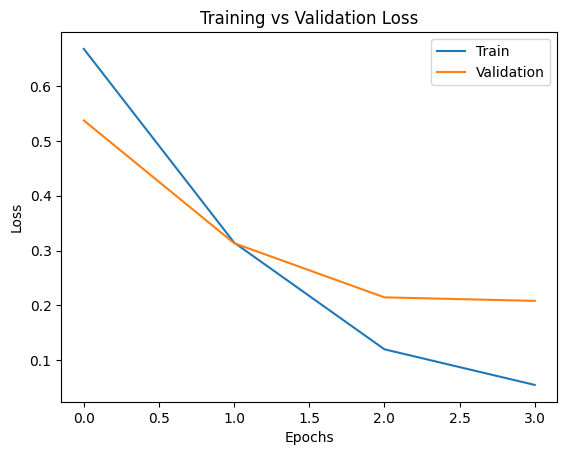

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.plot(val_losses)

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend(["Train", "Validation"])
plt.show()


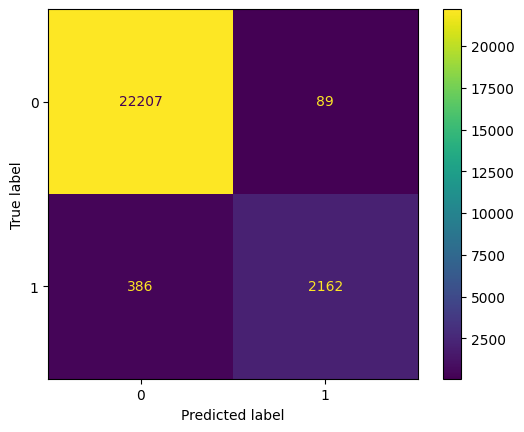

In [ ]:
y_true, y_pred = get_predictions(model, val_loader)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


النموذج الثاني

In [ ]:
import torch
import torch.nn as nn
import torchaudio
import pandas as pd
import numpy as np

from torch.utils.data import Dataset, DataLoader

from transformers import Wav2Vec2Model

In [ ]:
from sklearn.metrics import (
    recall_score,
    f1_score,
    roc_curve
)

import numpy as np

In [ ]:
wav2vec = Wav2Vec2Model.from_pretrained(
    "facebook/wav2vec2-base"
)

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
for param in wav2vec.parameters():
    param.requires_grad = False

In [ ]:
class VoiceDataset(Dataset):

    def __init__(self, df):

        self.df = df

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        waveform, sr = torchaudio.load(
            row['path']
        )

        waveform = preprocess_audio(
            waveform,
            sr
        )

        waveform = waveform.squeeze(0)

        label = torch.tensor(
            row['label']
        ).float()

        return waveform, label

In [ ]:
train_dataset = VoiceDataset(train_df)

val_dataset = VoiceDataset(dev_df)

In [ ]:
def collate_fn(batch):

    waveforms = []

    labels = []

    max_len = max([
        x[0].shape[0]
        for x in batch
    ])

    for waveform, label in batch:

        pad_size = max_len - waveform.shape[0]

        waveform = torch.nn.functional.pad(
            waveform,
            (0, pad_size)
        )

        waveforms.append(waveform)

        labels.append(label)

    waveforms = torch.stack(waveforms)

    labels = torch.stack(labels)

    return waveforms, labels

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=collate_fn
)

In [ ]:
class SSLDetector(nn.Module):

    def __init__(self):

        super().__init__()

        self.wav2vec = wav2vec

        self.classifier = nn.Sequential(

            nn.Linear(768, 256),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(256, 1)

        )

    def forward(self, x):

        outputs = self.wav2vec(x)

        embeddings = outputs.last_hidden_state

        embeddings = embeddings.mean(dim=1)

        out = self.classifier(
            embeddings
        )

        return out

In [ ]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = SSLDetector().to(device)

In [ ]:
weights = torch.tensor(
    class_weights,
    dtype=torch.float
).to(device)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=weights[1]
)

In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [ ]:
def train_epoch(model, loader):

    model.train()

    total_loss = 0

    for x, y in loader:

        x = x.to(device)

        y = y.float().unsqueeze(1).to(device)

        optimizer.zero_grad()

        out = model(x)

        loss = criterion(out, y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def eval_epoch(model, loader):

    model.eval()

    total_loss = 0

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)

            y = y.float().unsqueeze(1).to(device)

            out = model(x)

            loss = criterion(out, y)

            total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def calculate_metrics(model, loader):

    model.eval()

    all_scores = []
    all_preds = []
    all_labels = []

    with torch.no_grad():

        for x, y in loader:

            x = x.to(device)

            outputs = model(x)

            scores = torch.sigmoid(outputs)

            preds = (scores > 0.5).int()

            all_scores.extend(
                scores.cpu().numpy()
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                y.numpy()
            )

    all_scores = np.array(all_scores)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # =========================
    # Recall
    # =========================

    recall = recall_score(
        all_labels,
        all_preds
    )

    # =========================
    # F1-score
    # =========================

    f1 = f1_score(
        all_labels,
        all_preds
    )

    # =========================
    # EER
    # =========================

    fpr, tpr, thresholds = roc_curve(
        all_labels,
        all_scores
    )

    fnr = 1 - tpr

    eer = fpr[
        np.nanargmin(
            np.absolute(fnr - fpr)
        )
    ]

    return recall, f1, eer

In [ ]:
EPOCHS = 3

for epoch in range(EPOCHS):

    train_loss = train_epoch(
        model,
        train_loader
    )

    val_loss = eval_epoch(
        model,
        val_loader
    )

    recall, f1, eer = calculate_metrics(
        model,
        val_loader
    )

    print(f"\nEpoch {epoch+1}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Val Loss: {val_loss:.4f}")

    print(f"Recall: {recall:.4f}")

    print(f"F1-score: {f1:.4f}")

    print(f"EER: {eer:.4f}")


Epoch 1
Train Loss: 0.4723
Val Loss: 0.4320
Recall: 0.9666
F1-score: 0.5162
EER: 0.1009

Epoch 2
Train Loss: 0.2504
Val Loss: 0.4771
Recall: 0.9870
F1-score: 0.4779
EER: 0.0806

Epoch 3
Train Loss: 0.1848
Val Loss: 0.3065
Recall: 0.9721
F1-score: 0.6262
EER: 0.0690
